In [2]:
import pandas as pd

df = pd.read_csv('Space_Corrected.csv')

df.head()

,Unnamed: 0.1,Unnamed: 0,Company Name,Location,Datum,Detail,Status Rocket,Rocket,Status Mission
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success


In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (4324, 9)


In [5]:
null_counts = df.isnull().sum()
null_percentages = (df.isnull().sum() / len(df)) * 100

missing_data = pd.DataFrame({
    'Missing Values': null_counts,
    'Percentage (%)': null_percentages.round(2)
})
print("Missing Data Summary:")
print(missing_data)

Missing Data Summary:
                Missing Values  Percentage (%)
Unnamed: 0.1                 0            0.00
Unnamed: 0                   0            0.00
Company Name                 0            0.00
Location                     0            0.00
Datum                        0            0.00
Detail                       0            0.00
Status Rocket                0            0.00
 Rocket                   3360           77.71
Status Mission               0            0.00


In [6]:
# 3. Target Variable Distribution ('Status Mission')
print("Target Variable Distribution ('Status Mission'):")
print(df['Status Mission'].value_counts(dropna=False))
print("\nTarget Distribution (%):")
print(df['Status Mission'].value_counts(normalize=True, dropna=False).mul(100).round(2))

Target Variable Distribution ('Status Mission'):
Status Mission
Success              3879
Failure               339
Partial Failure       102
Prelaunch Failure       4
Name: count, dtype: int64

Target Distribution (%):
Status Mission
Success              89.71
Failure               7.84
Partial Failure       2.36
Prelaunch Failure     0.09
Name: proportion, dtype: float64


In [9]:
df.columns = df.columns.str.strip()
# 4. Evaluate Cost Data ('Rocket' column) Usability
total_rows = len(df)
cost_missing = df['Rocket'].isnull().sum()
cost_missing_pct = (cost_missing / total_rows) * 100

print(f"Cost ('Rocket') Missing: {cost_missing} / {total_rows} ({cost_missing_pct:.2f}%)")

if cost_missing_pct > 50:
    print("\nDecision Advice: 'Rocket' (cost) has a high proportion of missing values.")
    print("If your goal was predicting launch cost, consider pivoting to 'Status Mission' (classification) or dropping missing rows if predicting cost for high-budget launches specifically.")

Cost ('Rocket') Missing: 3360 / 4324 (77.71%)

Decision Advice: 'Rocket' (cost) has a high proportion of missing values.
If your goal was predicting launch cost, consider pivoting to 'Status Mission' (classification) or dropping missing rows if predicting cost for high-budget launches specifically.


In [10]:
df = df.dropna(subset=['Status Mission'])

cols_to_drop = ['Unnamed: 0.1', 'Unnamed: 0', 'Detail', 'Datum']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
if 'Rocket' in df.columns:
    df['Rocket'] = df['Rocket'].astype(str).str.replace(',', '').str.strip()
    df['Rocket'] = pd.to_numeric(df['Rocket'], errors='coerce')

print("Cleaned Dataset Shape:", df.shape)
print("\nRemaining Missing Values:")
print(df.isnull().sum())
print("\nCleaned Target Variable Counts:")
print(df['Status Mission'].value_counts())

Cleaned Dataset Shape: (4324, 5)

Remaining Missing Values:
Company Name         0
Location             0
Status Rocket        0
Rocket            3360
Status Mission       0
dtype: int64

Cleaned Target Variable Counts:
Status Mission
Success              3879
Failure               339
Partial Failure       102
Prelaunch Failure       4
Name: count, dtype: int64


In [18]:
import pandas as pd

# 1. Reload raw dataset
df = pd.read_csv('Space_Corrected.csv')

# 2. Clean column headers
df.columns = df.columns.str.strip()

# 3. Clean 'Rocket' (cost) column and drop rows where 'Rocket' is missing
df['Rocket'] = df['Rocket'].astype(str).str.replace(',', '').str.strip()
df['Rocket'] = pd.to_numeric(df['Rocket'], errors='coerce')
df = df.dropna(subset=['Rocket'])  # ~964 rows remain

# 4. Feature Engineering: Extract Year & Country
df['Year'] = pd.to_datetime(df['Datum'], errors='coerce').dt.year
df['Country'] = df['Location'].astype(str).apply(lambda x: x.split(',')[-1].strip())

# 5. Bucket rare companies into 'Other' to prevent one-hot column explosion
company_counts = df['Company Name'].value_counts()
rare_companies = company_counts[company_counts < 10].index
df['Company_Grouped'] = df['Company Name'].replace(rare_companies, 'Other')

# 6. Select features for regression and drop raw text metadata
cols_to_drop = ['Unnamed: 0.1', 'Unnamed: 0', 'Detail', 'Datum', 'Location', 'Company Name', 'Status Mission']
df_clean = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# 7. One-Hot Encode categorical features (drop_first=True avoids dummy variable trap)
categorical_cols = ['Company_Grouped', 'Country', 'Status Rocket']
df_encoded = pd.get_dummies(
    df_clean,
    columns=[c for c in categorical_cols if c in df_clean.columns],
    drop_first=True,
    dtype=int
)

# 8. Separate features (X) and target (y)
X = df_encoded.drop(columns=['Rocket'])
y = df_encoded['Rocket']

# Summary
print(f"Dataset shape after dropping missing costs: {df_encoded.shape}")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print("\nFirst 10 feature columns:")
print(X.columns[:10].tolist())

Dataset shape after dropping missing costs: (964, 28)
Features (X) shape: (964, 27)
Target (y) shape: (964,)

First 10 feature columns:
['Year', 'Company_Grouped_CASC', 'Company_Grouped_Eurockot', 'Company_Grouped_ILS', 'Company_Grouped_ISRO', 'Company_Grouped_Kosmotras', 'Company_Grouped_MHI', 'Company_Grouped_NASA', 'Company_Grouped_Northrop', 'Company_Grouped_Other']


In [19]:
df_encoded.head()

,Rocket,Year,Company_Grouped_CASC,Company_Grouped_Eurockot,Company_Grouped_ILS,Company_Grouped_ISRO,Company_Grouped_Kosmotras,Company_Grouped_MHI,Company_Grouped_NASA,Company_Grouped_Northrop,...,Country_Gran Canaria,Country_India,Country_Japan,Country_Kazakhstan,Country_New Zealand,Country_Pacific Missile Range Facility,Country_Russia,Country_USA,Country_Yellow Sea,Status Rocket_StatusRetired
0,50.00,2020.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,29.75,2020.0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,65.00,2020.0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,145.00,2020.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
5,64.68,2020.0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Ensure X and y are cleanly aligned and free of NaNs
# Drop any rows in X or y that still contain missing values
df_model = df_encoded.dropna().copy()

X = df_model.drop(columns=['Rocket'])
y = df_model['Rocket']

# 2. Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Fit Baseline Linear Regression Model
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

# 4. Generate Predictions
y_train_pred = baseline_model.predict(X_train)
y_test_pred = baseline_model.predict(X_test)

# 5. Calculate Metrics (R² and RMSE)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Display Performance Results
print("--- Baseline Linear Regression Performance ---")
print(f"Train R²:   {train_r2:.4f}")
print(f"Test R²:    {test_r2:.4f}")
print(f"Train RMSE: ${train_rmse:.2f}M")
print(f"Test RMSE:  ${test_rmse:.2f}M")

--- Baseline Linear Regression Performance ---
Train R²:   0.5799
Test R²:    0.4581
Train RMSE: $169.48M
Test RMSE:  $279.33M


In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ridge = Ridge(alpha=10.0, random_state=42)
ridge.fit(X_train_scaled, y_train)

lasso = Lasso(alpha=1.0, random_state=42)
lasso.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)
y_pred_lasso = lasso.predict(X_test_scaled)

ridge_test_r2 = r2_score(y_test, y_pred_ridge)
ridge_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

lasso_test_r2 = r2_score(y_test, y_pred_lasso)
lasso_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

print("=================== TEST PERFORMANCE COMPARISON ===================")
print(f"Baseline Linear Regression | Test R²: {test_r2:.4f} | Test RMSE: ${test_rmse:.2f}M")
print(f"Ridge Regression (L2)      | Test R²: {ridge_test_r2:.4f} | Test RMSE: ${ridge_test_rmse:.2f}M")
print(f"Lasso Regression (L1)      | Test R²: {lasso_test_r2:.4f} | Test RMSE: ${lasso_test_rmse:.2f}M")
print("===================================================================\n")

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Baseline_Coef': baseline_model.coef_,
    'Ridge_Coef': ridge.coef_,
    'Lasso_Coef': lasso.coef_
})

zeroed_features = coef_df[coef_df['Lasso_Coef'] == 0]['Feature'].tolist()
retained_features = coef_df[coef_df['Lasso_Coef'] != 0]['Feature'].tolist()

print(f"Total Features: {len(X.columns)}")
print(f"Features Retained by Lasso: {len(retained_features)}")
print(f"Features Zeroed Out by Lasso: {len(zeroed_features)}\n")

print("--- Features Zeroed Out by Lasso (Dropped Features) ---")
for feat in zeroed_features:
    print(f" • {feat}")

print("\n--- Top Coefficient Comparison (First 10 Features) ---")
print(coef_df.head(10).round(2).to_string(index=False))

=================== TEST PERFORMANCE COMPARISON ===================
Baseline Linear Regression | Test R²: 0.4581 | Test RMSE: $279.33M
Ridge Regression (L2)      | Test R²: 0.3946 | Test RMSE: $295.23M
Lasso Regression (L1)      | Test R²: 0.4041 | Test RMSE: $292.92M

Total Features: 27
Features Retained by Lasso: 21
Features Zeroed Out by Lasso: 6

--- Features Zeroed Out by Lasso (Dropped Features) ---
 • Company_Grouped_Rocket Lab
 • Country_Japan
 • Country_New Zealand
 • Country_Pacific Missile Range Facility
 • Country_USA
 • Country_Yellow Sea

--- Top Coefficient Comparison (First 10 Features) ---
                  Feature  Baseline_Coef  Ridge_Coef  Lasso_Coef
                     Year          -7.55      -90.87      -88.38
     Company_Grouped_CASC         383.85      -32.19       -5.70
 Company_Grouped_Eurockot        -965.34      -87.53     -116.17
      Company_Grouped_ILS        -221.19      -37.70      -52.56
     Company_Grouped_ISRO         191.95      -11.09       -0

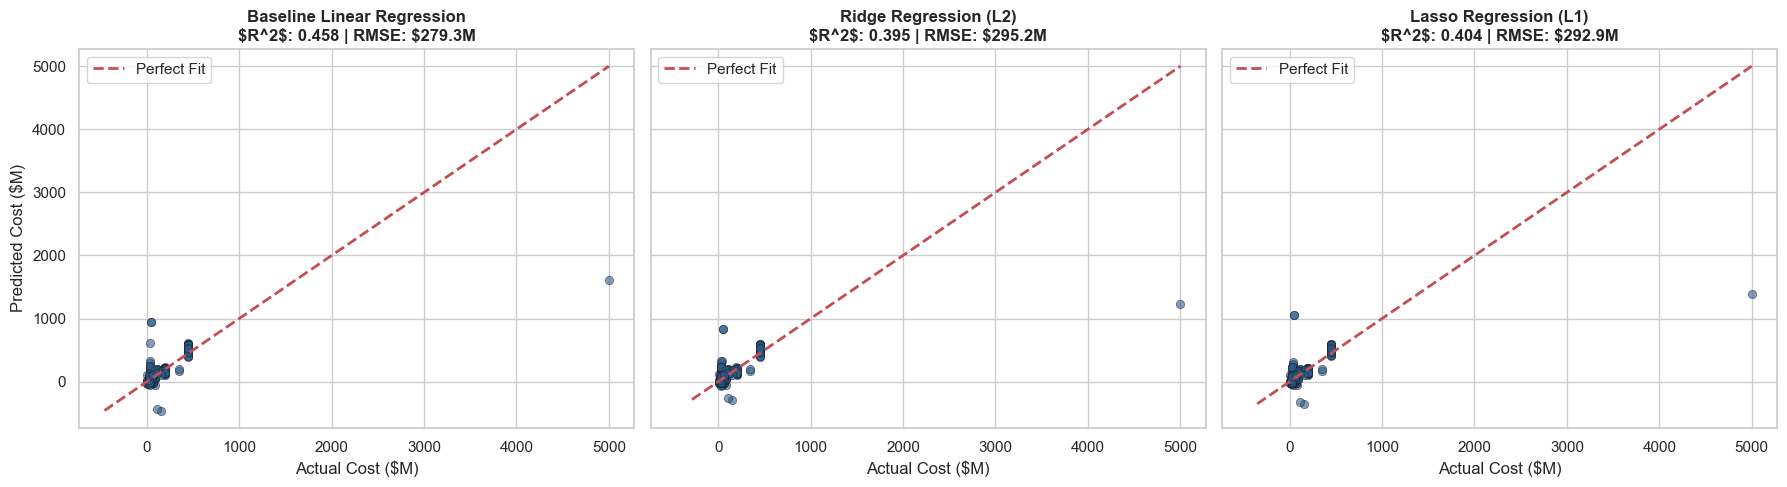

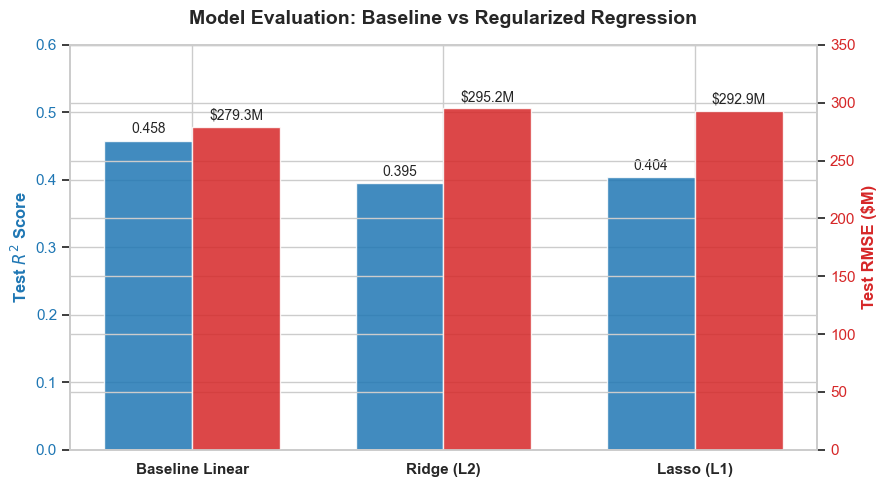

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set figure style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11})

# 1. PREDICTED VS ACTUAL SCATTER PLOTS
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True, sharex=True)

models = [
    ('Baseline Linear Regression', baseline_model.predict(X_test), test_r2, test_rmse),
    ('Ridge Regression (L2)', y_pred_ridge, ridge_test_r2, ridge_test_rmse),
    ('Lasso Regression (L1)', y_pred_lasso, lasso_test_r2, lasso_test_rmse)
]

for ax, (name, y_pred, r2, rmse) in zip(axes, models):
    # Scatter plot
    ax.scatter(y_test, y_pred, alpha=0.6, color='#2b5c8f', edgecolors='k', linewidth=0.5)
    
    # 45-degree Perfect Prediction Line
    max_val = max(y_test.max(), y_pred.max())
    min_val = min(y_test.min(), y_pred.min())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')
    
    ax.set_title(f"{name}\n$R^2$: {r2:.3f} | RMSE: ${rmse:.1f}M", fontsize=12, fontweight='bold')
    ax.set_xlabel('Actual Cost ($M)')
    if ax == axes[0]:
        ax.set_ylabel('Predicted Cost ($M)')
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

# 2. MODEL COMPARISON BAR CHART (R² AND RMSE)
model_names = ['Baseline Linear', 'Ridge (L2)', 'Lasso (L1)']
r2_scores = [test_r2, ridge_test_r2, lasso_test_r2]
rmse_scores = [test_rmse, ridge_test_rmse, lasso_test_rmse]

fig, ax1 = plt.subplots(figsize=(9, 5))

x = np.arange(len(model_names))
width = 0.35

# Primary Axis: Test R² Score
color1 = '#1f77b4'
rects1 = ax1.bar(x - width/2, r2_scores, width, label='Test R²', color=color1, alpha=0.85)
ax1.set_ylabel('Test $R^2$ Score', color=color1, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(0, 0.6)

# Secondary Axis: Test RMSE ($M)
ax2 = ax1.twinx()
color2 = '#d62728'
rects2 = ax2.bar(x + width/2, rmse_scores, width, label='Test RMSE ($M)', color=color2, alpha=0.85)
ax2.set_ylabel('Test RMSE ($M)', color=color2, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(0, 350)

# Labels and Formatting
ax1.set_xticks(x)
ax1.set_xticklabels(model_names, fontweight='bold')
plt.title('Model Evaluation: Baseline vs Regularized Regression', fontsize=14, fontweight='bold', pad=15)

for rect in rects1:
    height = rect.get_height()
    ax1.annotate(f'{height:.3f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

for rect in rects2:
    height = rect.get_height()
    ax2.annotate(f'${height:.1f}M',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

fig.tight_layout()
plt.show()

In [26]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# 1. Test a range of smaller alpha values for Ridge and Lasso
alphas_to_test = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]

results = []

for a in alphas_to_test:
    # Ridge
    ridge_m = Ridge(alpha=a, random_state=42)
    ridge_m.fit(X_train_scaled, y_train)
    r_tr_r2 = ridge_m.score(X_train_scaled, y_train)
    r_te_r2 = ridge_m.score(X_test_scaled, y_test)
    r_te_rmse = np.sqrt(mean_squared_error(y_test, ridge_m.predict(X_test_scaled)))
    
    results.append({
        'Model': 'Ridge',
        'Alpha': a,
        'Train R²': round(r_tr_r2, 4),
        'Test R²': round(r_te_r2, 4),
        'Gap (Train-Test)': round(r_tr_r2 - r_te_r2, 4),
        'Test RMSE ($M)': round(r_te_rmse, 2)
    })
    
    # Lasso
    lasso_m = Lasso(alpha=a, random_state=42, max_iter=10000)
    lasso_m.fit(X_train_scaled, y_train)
    l_tr_r2 = lasso_m.score(X_train_scaled, y_train)
    l_te_r2 = lasso_m.score(X_test_scaled, y_test)
    l_te_rmse = np.sqrt(mean_squared_error(y_test, lasso_m.predict(X_test_scaled)))
    
    results.append({
        'Model': 'Lasso',
        'Alpha': a,
        'Train R²': round(l_tr_r2, 4),
        'Test R²': round(l_te_r2, 4),
        'Gap (Train-Test)': round(l_tr_r2 - l_te_r2, 4),
        'Test RMSE ($M)': round(l_te_rmse, 2)
    })

results_df = pd.DataFrame(results)

print("--- Baseline Baseline Performance Reference ---")
print(f"Baseline Train R²: 0.5799 | Test R²: 0.4581 | Gap: 0.1218 | Test RMSE: $279.33M\n")

print("--- Regularization Alpha Search ---")
print(results_df.to_string(index=False))

--- Baseline Baseline Performance Reference ---
Baseline Train R²: 0.5799 | Test R²: 0.4581 | Gap: 0.1218 | Test RMSE: $279.33M

--- Regularization Alpha Search ---
Model  Alpha  Train R²  Test R²  Gap (Train-Test)  Test RMSE ($M)
Ridge   0.01    0.5799   0.4237            0.1562          288.05
Lasso   0.01    0.5799   0.4097            0.1702          291.53
Ridge   0.10    0.5799   0.4241            0.1559          287.96
Lasso   0.10    0.5799   0.4148            0.1651          290.28
Ridge   0.50    0.5798   0.4249            0.1548          287.74
Lasso   0.50    0.5786   0.4109            0.1677          291.22
Ridge   1.00    0.5794   0.4249            0.1546          287.76
Lasso   1.00    0.5753   0.4041            0.1712          292.92
Ridge   5.00    0.5749   0.4130            0.1619          290.72
Lasso   5.00    0.4873   0.2450            0.2423          329.70
Ridge  10.00    0.5675   0.3946            0.1729          295.23
Lasso  10.00    0.4611   0.2012            